# US 4.2.1 — VAE para Imputación Probabilística de Series Temporales

**Entregable:** Notebook + métricas de desempeño
**Criterio de aceptación:** Imputaciones coherentes con la distribución original

## Descripción
Implementa un **Variational Autoencoder (VAE)** convolucional 1-D en PyTorch para imputación probabilística de datos hidrometeorológicos de Sinaloa. El modelo aprende una distribución en el espacio latente que permite generar múltiples realizaciones plausibles para cada posición faltante, cuantificando incertidumbre.

## Arquitectura
```
Encoder:  (N,T,F) → Conv1d × 3 → AdaptiveAvgPool1d(8) → FC(128) → μ ∈ R^64, logσ² ∈ R^64
Decoder:  z ∈ R^64 → FC → Unflatten(128,8) → Upsample(30) → Conv1d × 3 → (N,T,F)
```

## Función de pérdida (β-VAE ELBO)
```
L = masked_MSE(x_recon, x, mask) + β · KL(q(z|x) ‖ p(z))
KL = -½ Σ(1 + logσ² - μ² - e^logσ²)
```

## Evaluación MCAR
Se enmascara artificialmente el 20 % de los valores observados del test set.

## Métricas: RMSE · MAE · MAPE · R² · NSE · KPSS · ACF/PACF

| Métrica | Descripción |
|---------|-------------|
| RMSE / MAE / MAPE | Error puntual en espacio escalado |
| R² / NSE | Bondad de ajuste (NSE > 0.6: buen resultado) |
| KPSS | Estacionariedad: H₀ serie estacionaria — preservación del régimen temporal |
| ACF/PACF | Estructura de autocorrelación (21 lags): original vs imputado |


In [13]:
from pathlib import Path
import time, json, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path("__file__").resolve().parent.parent
TENSORS_DIR  = PROJECT_ROOT / "data" / "tensors"
MODELS_DIR   = PROJECT_ROOT / "models" / "modelos_generativos"
REPORTS_DIR  = PROJECT_ROOT / "reports" / "modelos_generativos"
FIGURES_DIR  = REPORTS_DIR / "figuras"
for d in [MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'
VARIABLES = ["precip", "evap", "tmax", "tmin"]

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"PROJECT : {PROJECT_ROOT}")


Device  : cpu
PyTorch : 2.11.0+cu130
PROJECT : /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main


## 1 — Carga de tensores

In [14]:
def load_tensor(path: Path) -> torch.Tensor:
    try:
        return torch.load(path, weights_only=True)
    except TypeError:
        return torch.load(path)

X_train = load_tensor(TENSORS_DIR / "X_train.pt")
M_train = load_tensor(TENSORS_DIR / "mask_train.pt")
X_val   = load_tensor(TENSORS_DIR / "X_val.pt")
M_val   = load_tensor(TENSORS_DIR / "mask_val.pt")
X_test  = load_tensor(TENSORS_DIR / "X_test.pt")
M_test  = load_tensor(TENSORS_DIR / "mask_test.pt")

with open(TENSORS_DIR / "tensors_metadata.json") as f:
    meta = json.load(f)

N_FEAT   = X_train.shape[2]   # 4
WIN_SIZE = X_train.shape[1]   # 30

print(f"X_train : {tuple(X_train.shape)}  |  obs_rate={M_train.mean():.3f}")
print(f"X_val   : {tuple(X_val.shape)}  |  obs_rate={M_val.mean():.3f}")
print(f"X_test  : {tuple(X_test.shape)}  |  obs_rate={M_test.mean():.3f}")
print(f"\nWindow size : {meta['config']['window_size']}")
print(f"Variables   : {meta['feature_names']}")


X_train : (160041, 30, 4)  |  obs_rate=0.857
X_val   : (33831, 30, 4)  |  obs_rate=0.915
X_test  : (33678, 30, 4)  |  obs_rate=0.865

Window size : 30
Variables   : ['precip', 'evap', 'tmax', 'tmin']


In [15]:
BATCH_SIZE  = 256
EPOCHS      = 80
LR          = 1e-3
LATENT_DIM  = 64
BETA        = 0.5      # peso del término KL en β-VAE
PATIENCE    = 12
MCAR_RATE   = 0.20

train_ds = TensorDataset(X_train, M_train)
val_ds   = TensorDataset(X_val,   M_val)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, pin_memory=(DEVICE=='cuda'))
print(f"Batches train: {len(train_loader)}  |  val: {len(val_loader)}")


Batches train: 626  |  val: 133


## 2 — Arquitectura del VAE

In [16]:
class VAE(nn.Module):
    """
    Variational Autoencoder convolucional 1-D.
    Entrada/Salida: (N, T, F)
    Internamente opera en (N, F, T) para Conv1d.
    """
    def __init__(self, n_features: int = 4, window: int = 30, latent_dim: int = 64):
        super().__init__()
        self.n_features = n_features
        self.window     = window
        self.latent_dim = latent_dim
        H = 128

        # Encoder
        self.enc_conv = nn.Sequential(
            nn.Conv1d(n_features, 32, 3, padding=1), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,  64,    3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,  H,     3, padding=1), nn.BatchNorm1d(H),   nn.ReLU(),
            nn.AdaptiveAvgPool1d(8), nn.Flatten(),
        )
        self.fc_enc  = nn.Sequential(nn.Linear(H * 8, 256), nn.ReLU())
        self.fc_mu   = nn.Linear(256, latent_dim)
        self.fc_logv = nn.Linear(256, latent_dim)

        # Decoder
        self.fc_dec = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, H * 8),      nn.ReLU(),
        )
        self.dec_conv = nn.Sequential(
            nn.Unflatten(1, (H, 8)),
            nn.Upsample(size=window, mode='linear', align_corners=False),
            nn.Conv1d(H,  64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 32, 3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, n_features, 3, padding=1),
        )

    def encode(self, x: torch.Tensor):
        h = self.fc_enc(self.enc_conv(x.permute(0, 2, 1)))
        return self.fc_mu(h), self.fc_logv(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.dec_conv(self.fc_dec(z)).permute(0, 2, 1)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


def vae_loss(recon, x, mask, mu, logvar, beta: float = 0.5):
    recon_loss = ((recon - x) ** 2 * mask).sum() / (mask.sum() + 1e-8)
    kl         = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss.item(), kl.item()


model = VAE(n_features=N_FEAT, window=WIN_SIZE, latent_dim=LATENT_DIM).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total:,}")
print(model)


Parámetros totales: 638,276
VAE(
  (enc_conv): Sequential(
    (0): Conv1d(4, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): AdaptiveAvgPool1d(output_size=8)
    (10): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_enc): Sequential(
    (0): Linear(in_features=1024, out_features=256, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=256, out_features=64, bias=True)
  (fc_logv): Linear(in_features=256, out_features=64, bias=True)
  (fc_dec): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): 

## 3 — Entrenamiento

Protocolo de entrenamiento por denoising MCAR:
- **Optimizador:** Adam (lr=1e-3, weight_decay=1e-5) con ReduceLROnPlateau (factor=0.5, patience=6)
- **Épocas:** 80 máximo · **Early stopping:** patience=12 sobre val_loss
- **Grad clipping:** norm=1.0 para estabilidad
- **Estrategia:** en cada batch se enmascara aleatoriamente el 20 % de los valores observados (MCAR) → el modelo recibe la secuencia con esos valores en cero y se penaliza únicamente en las posiciones enmascaradas (Masked MSE). El término KL regulariza el espacio latente hacia N(0,I) con peso β=0.5.

In [17]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 'min', patience=6, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'kl': []}
best_val, patience_ctr, best_state = float('inf'), 0, None

print(f"{'Época':>6}  {'Train':>10}  {'Val':>10}  {'KL':>8}  {'LR':>8}  {'t':>6}")
print('─' * 58)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_loss, tr_kl = 0.0, 0.0
    for Xb, Mb in train_loader:
        Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
        rand   = torch.rand_like(Mb)
        vis    = Mb * (rand > MCAR_RATE).float()
        Xin    = Xb * vis
        recon, mu, logvar = model(Xin)
        loss, rl, kl = vae_loss(recon, Xb, Mb * (rand <= MCAR_RATE).float(),
                                 mu, logvar, BETA)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item() * len(Xb); tr_kl += kl * len(Xb)
    tr_loss /= len(train_loader.dataset)
    tr_kl   /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, Mb in val_loader:
            Xb, Mb = Xb.to(DEVICE), Mb.to(DEVICE)
            rand   = torch.rand_like(Mb)
            vis    = Mb * (rand > MCAR_RATE).float()
            Xin    = Xb * vis
            recon, mu, logvar = model(Xin)
            loss, *_ = vae_loss(recon, Xb, Mb * (rand <= MCAR_RATE).float(),
                                 mu, logvar, BETA)
            val_loss += loss.item() * len(Xb)
    val_loss /= len(val_loader.dataset)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['kl'].append(tr_kl)
    scheduler.step(val_loss)
    lr_now = optimizer.param_groups[0]['lr']

    print(f"{epoch:>6}  {tr_loss:>10.6f}  {val_loss:>10.6f}  "
          f"{tr_kl:>8.5f}  {lr_now:>8.2e}  {time.time()-t0:>4.1f}s")

    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping en época {epoch}.")
            break

model.load_state_dict(best_state)
print(f"\nMejor val_loss: {best_val:.6f}")


 Época       Train         Val        KL        LR       t
──────────────────────────────────────────────────────────
     1    0.172939    0.150674   0.07127  1.00e-03  16.6s
     2    0.141996    0.142264   0.06335  1.00e-03  16.4s
     3    0.140200    0.142438   0.06338  1.00e-03  16.6s
     4    0.138736    0.142155   0.06355  1.00e-03  16.5s
     5    0.138330    0.140332   0.06382  1.00e-03  16.4s
     6    0.137217    0.141515   0.06407  1.00e-03  16.6s
     7    0.137041    0.139660   0.06448  1.00e-03  16.7s
     8    0.136621    0.140028   0.06487  1.00e-03  16.5s
     9    0.136472    0.138127   0.06547  1.00e-03  16.5s
    10    0.135801    0.138059   0.06573  1.00e-03  16.5s
    11    0.135194    0.139014   0.06608  1.00e-03  16.7s
    12    0.135284    0.139197   0.06615  1.00e-03  16.6s
    13    0.134767    0.140839   0.06607  1.00e-03  16.7s
    14    0.134780    0.137010   0.06623  1.00e-03  16.8s
    15    0.134436    0.138008   0.06633  1.00e-03  16.5s
    16    0.

Modelo guardado.


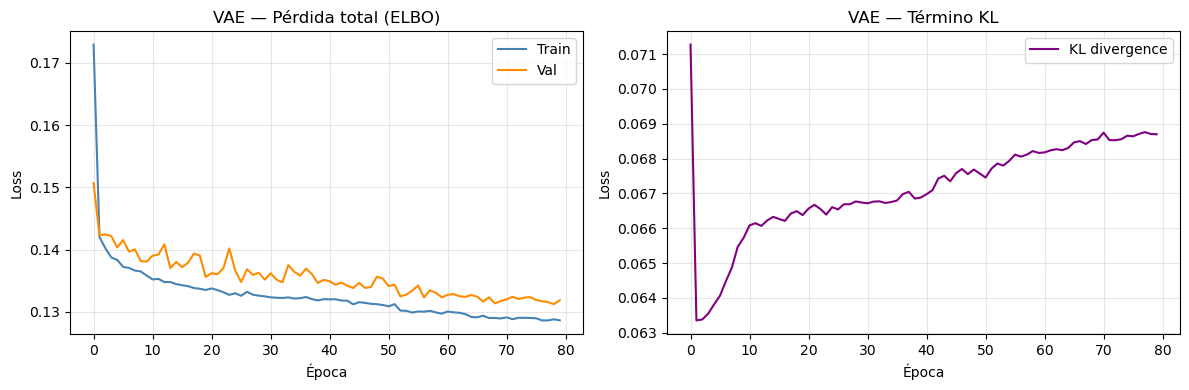

In [18]:
torch.save({'model_state_dict': model.state_dict(),
            'config': {'n_features': N_FEAT, 'window': WIN_SIZE,
                       'latent_dim': LATENT_DIM, 'beta': BETA},
            'best_val_loss': best_val},
           MODELS_DIR / "vae_best.pt")
print(f"Modelo guardado.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val',   color='darkorange')
axes[0].set_title('VAE — Pérdida total (ELBO)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history['kl'], color='purple', label='KL divergence')
axes[1].set_title('VAE — Término KL'); axes[1].legend(); axes[1].grid(alpha=0.3)
for ax in axes:
    ax.set_xlabel('Época'); ax.set_ylabel('Loss')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vae_learning_curve.png", dpi=120, bbox_inches='tight')
plt.show()


## 4 — Evaluación MCAR

Protocolo estándar MCAR 20 % aplicado al test set:
1. Se seleccionan secuencias con ≥ 70 % de observaciones reales.
2. Se enmascara artificialmente el 20 % de esas observaciones (posiciones `gt_mask`).
3. El modelo recibe la secuencia con los valores enmascarados en cero (`ev_mask`).
4. Se promedian **10 muestras** del espacio latente para reducir varianza estocástica antes de calcular métricas.
5. Las métricas se calculan **solo** sobre las posiciones artificialmente enmascaradas.

In [19]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, var_name: str) -> dict:
    eps = 1e-8
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    mape = float(np.mean(np.abs(y_true - y_pred) / (np.abs(y_true) + eps)) * 100)
    r2   = float(r2_score(y_true, y_pred))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    nse  = float(1 - ss_res / (ss_tot + eps))
    return {"variable": var_name, "rmse": rmse, "mae": mae, "mape": mape,
            "r2": r2, "nse": nse}

@torch.no_grad()
def evaluate_mcar_vae(model, X_test, M_test, mcar_rate=0.20,
                      min_obs=0.70, batch_size=512, n_samples=1):
    """Protocolo MCAR 20 %. Para VAE usa media de n_samples muestras."""
    torch.manual_seed(42)
    model.eval().to(DEVICE)

    obs_rate = M_test.mean(dim=(1, 2))
    sel      = obs_rate >= min_obs
    Xs, Ms   = X_test[sel], M_test[sel]
    print(f"  Secuencias con obs≥{min_obs*100:.0f}%: {Xs.shape[0]:,} / {X_test.shape[0]:,}")

    rand    = torch.rand_like(Ms)
    ev_mask = Ms * (rand > mcar_rate).float()
    gt_mask = Ms * (rand <= mcar_rate).float()
    Xin     = Xs * ev_mask

    preds_list = []
    for _ in range(n_samples):
        preds = []
        ds = TensorDataset(Xin, ev_mask)
        for Xb, _ in DataLoader(ds, batch_size, shuffle=False):
            recon, *_ = model(Xb.to(DEVICE))
            preds.append(recon.cpu())
        preds_list.append(torch.cat(preds, 0))

    preds_mean = torch.stack(preds_list).mean(0)   # (N, T, F)

    results = {}
    for fi, var in enumerate(VARIABLES):
        gm = gt_mask[:, :, fi].bool()
        yt = Xs[:, :, fi][gm].numpy()
        yp = preds_mean[:, :, fi][gm].numpy()
        m  = compute_metrics(yt, yp, var)
        m['n_mcar'] = len(yt)
        results[var] = m
        print(f"  {var}: {len(yt):,} pts  RMSE={m['rmse']:.4f}  NSE={m['nse']:.4f}")
    return results, preds_mean, Xs, Ms, ev_mask, gt_mask

print("Evaluando VAE (MCAR 20%, 10 muestras promediadas) ...")
vae_eval, preds, Xs, Ms, ev_m, gt_m = evaluate_mcar_vae(
    model, X_test, M_test, mcar_rate=MCAR_RATE, n_samples=10)


Evaluando VAE (MCAR 20%, 10 muestras promediadas) ...
  Secuencias con obs≥70%: 32,661 / 33,678
  precip: 196,368 pts  RMSE=0.0225  NSE=0.0416
  evap: 100,832 pts  RMSE=0.0815  NSE=0.3351
  tmax: 195,614 pts  RMSE=0.4455  NSE=0.8042
  tmin: 195,037 pts  RMSE=0.3179  NSE=0.9022


## 5 — Visualización de reconstrucciones

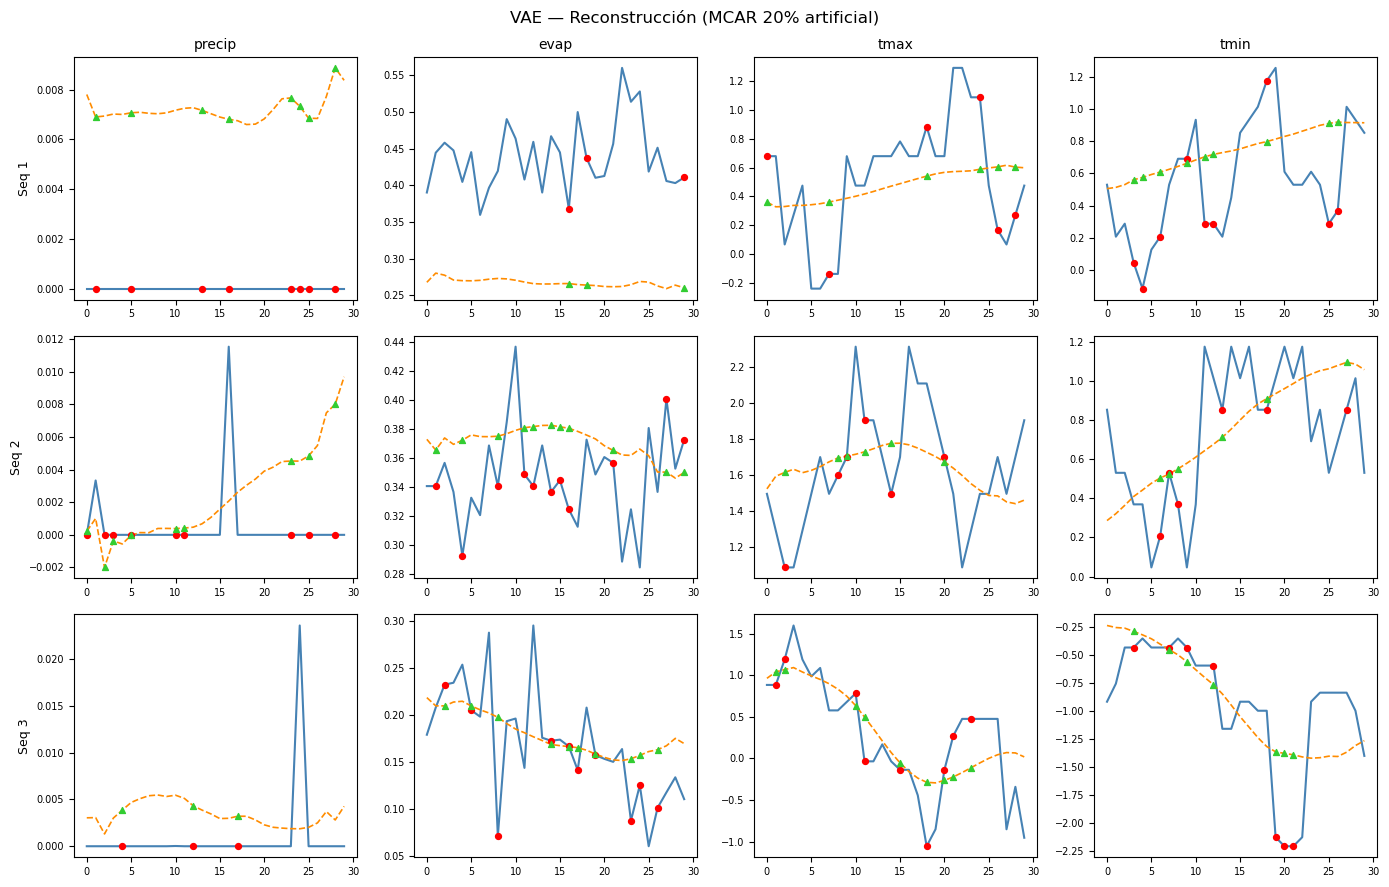

In [20]:
# ─── Reconstrucciones ────────────────────────────────────────────────────────
torch.manual_seed(7)
obs_r   = Ms.mean(dim=(1,2))
hi      = torch.where(obs_r > 0.90)[0]
sidxs   = hi[torch.randperm(len(hi))[:3]]
days    = np.arange(WIN_SIZE)

fig, axes = plt.subplots(3, N_FEAT, figsize=(14, 9))
fig.suptitle('VAE — Reconstrucción (MCAR 20% artificial)', fontsize=12)

for row, si in enumerate(sidxs.tolist()):
    for col, var in enumerate(VARIABLES):
        ax   = axes[row, col]
        orig = Xs[si, :, col].numpy()
        rec  = preds[si, :, col].numpy()
        gm   = gt_m[si, :, col].bool().numpy()
        ax.plot(days, orig, 'steelblue', lw=1.5, label='Original')
        ax.plot(days, rec,  'darkorange', lw=1.2, ls='--', label='VAE')
        ax.scatter(days[gm], orig[gm], color='red',       s=18, zorder=5)
        ax.scatter(days[gm], rec[gm],  color='limegreen', s=18, zorder=6, marker='^')
        if row == 0: ax.set_title(var, fontsize=10)
        if col == 0: ax.set_ylabel(f'Seq {row+1}', fontsize=9)
        ax.tick_params(labelsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vae_reconstruccion.png", dpi=120, bbox_inches='tight')
plt.show()


## 6 — Comparación de distribuciones: original vs imputado

Verificación del criterio de aceptación: **"Salidas coherentes con distribución original"**.  
Se comparan las densidades KDE de los valores reales vs. los imputados en las posiciones MCAR.  
Una buena imputación produce curvas superpuestas o muy cercanas.

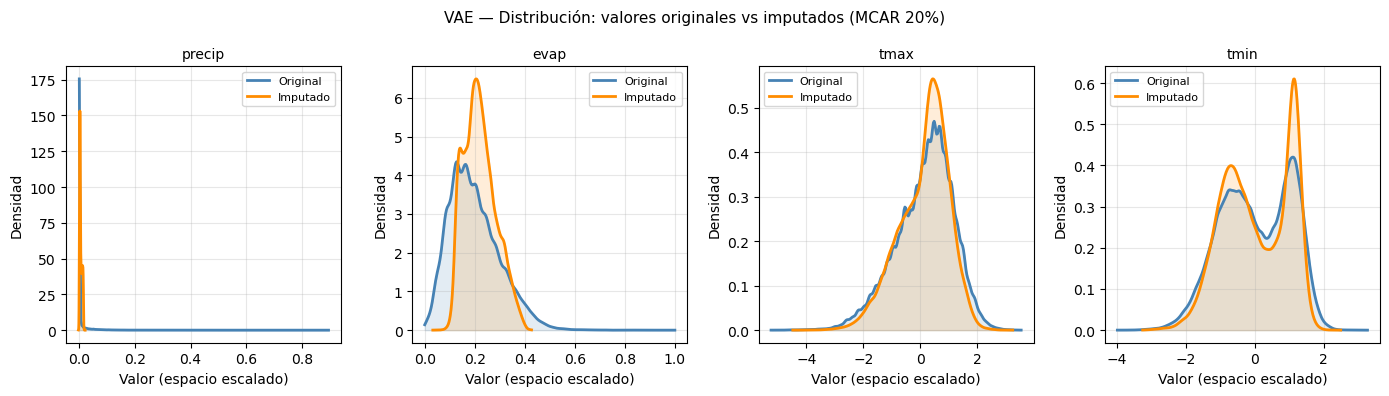

AC: distribuciones coherentes si las curvas KDE se superponen correctamente.


In [21]:
# ─── KDE: distribución original vs imputado (posiciones MCAR) ───────────────
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, N_FEAT, figsize=(14, 4))
fig.suptitle('VAE — Distribución: valores originales vs imputados (MCAR 20%)', fontsize=11)

for fi, var in enumerate(VARIABLES):
    ax     = axes[fi]
    gm     = gt_m[:, :, fi].bool()
    y_orig = Xs[:, :, fi][gm].numpy()
    y_pred = preds[:, :, fi][gm].numpy()

    for vals, color, label in [
        (y_orig, 'steelblue',  'Original'),
        (y_pred, 'darkorange', 'Imputado'),
    ]:
        kde  = gaussian_kde(vals, bw_method='scott')
        xmin, xmax = float(vals.min()), float(vals.max())
        xs   = np.linspace(xmin, xmax, 300)
        ax.plot(xs, kde(xs), color=color, lw=2, label=label)
        ax.fill_between(xs, kde(xs), alpha=0.15, color=color)

    ax.set_title(var, fontsize=10)
    ax.set_xlabel('Valor (espacio escalado)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vae_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print("AC: distribuciones coherentes si las curvas KDE se superponen correctamente.")

## 7 — Validación temporal: KPSS y ACF/PACF

Verificación de que la imputación preserva la **estructura estadística temporal** de las series originales.
- **KPSS**: prueba de estacionariedad (H₀: la serie es estacionaria). Resultado coherente si ambas series dan el mismo veredicto.
- **ACF/PACF**: compara la autocorrelación y autocorrelación parcial antes y después de imputar.

=== KPSS: Estacionariedad (H₀: estacionaria) ===
Variable  Stat_orig   p_orig    Stat_imp    p_imp     ¿Preserva?
─────────────────────────────────────────────────────────────────
precip    0.2287      0.1000    0.1276      0.1000    ✓ Sí
evap      0.1772      0.1000    0.1237      0.1000    ✓ Sí
tmax      0.4415      0.0593    0.3714      0.0895    ✓ Sí
tmin      0.1453      0.1000    0.1442      0.1000    ✓ Sí

KPSS guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/kpss_vae.csv
ACF/PACF guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/acf_pacf_vae.csv


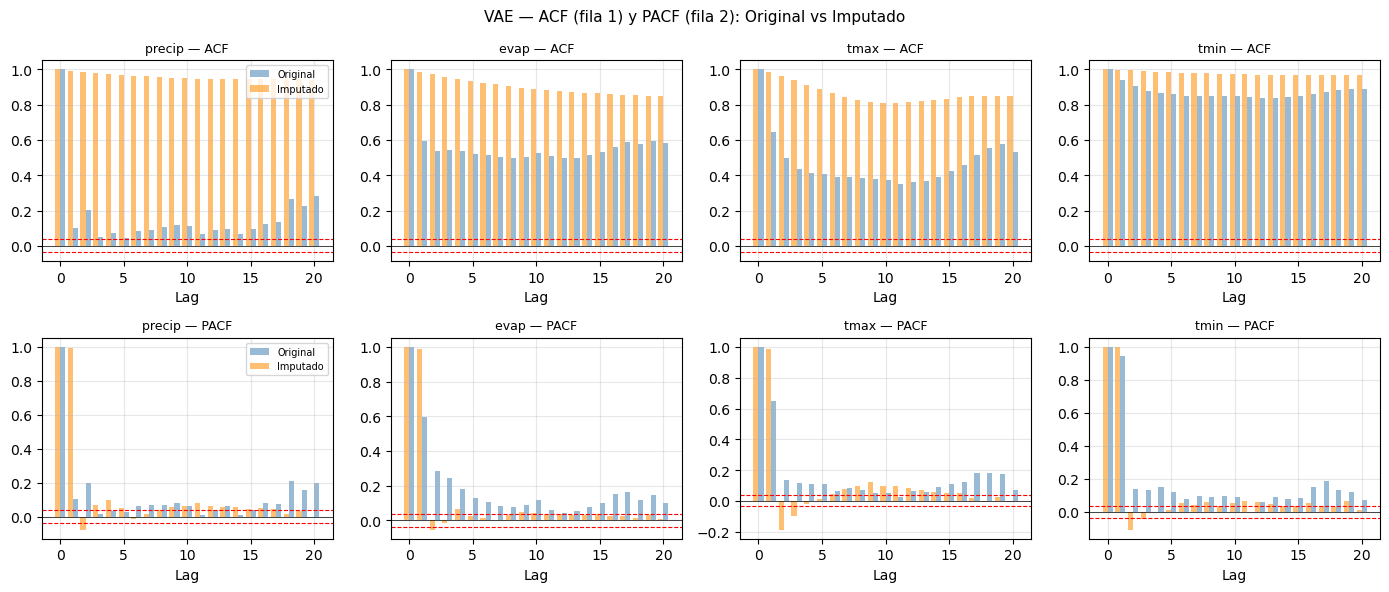

Validación temporal completada.
Metricas unificadas guardadas: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/metrics_vae.csv


In [22]:
from statsmodels.tsa.stattools import kpss, acf, pacf
import warnings

N_LAGS = 20

# ─── KPSS + ACF/PACF: calcular, mostrar y guardar ────────────────────────────
print("=== KPSS: Estacionariedad (H₀: estacionaria) ===")
print(f"{"Variable":<8}  {"Stat_orig":<10}  {"p_orig":<8}  {"Stat_imp":<10}  {"p_imp":<8}  {"¿Preserva?"}")
print("─" * 65)

kpss_rows, acf_rows = [], []

for fi, var in enumerate(VARIABLES):
    obs_m  = ev_m[:, :, fi].bool()
    y_orig = Xs[:, :, fi][obs_m].numpy()[:5000]
    y_pred = preds[:, :, fi][obs_m].numpy()[:5000]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        stat_o, p_o, *_ = kpss(y_orig, regression="c", nlags="auto")
        stat_i, p_i, *_ = kpss(y_pred, regression="c", nlags="auto")
    preserva = bool((p_o > 0.05) == (p_i > 0.05))
    ok = "✓ Sí" if preserva else "✗ No"
    print(f"{var:<8}  {stat_o:<10.4f}  {p_o:<8.4f}  {stat_i:<10.4f}  {p_i:<8.4f}  {ok}")
    kpss_rows.append({"modelo": "VAE", "variable": var,
                       "stat_orig": round(stat_o, 4), "p_orig": round(p_o, 4),
                       "stat_imp":  round(stat_i, 4), "p_imp":  round(p_i, 4),
                       "preserva_estacionariedad": preserva})

    n_s   = min(len(y_orig), 3000)
    acf_o = acf(y_orig[:n_s],  nlags=N_LAGS, fft=True)
    acf_i = acf(y_pred[:n_s],  nlags=N_LAGS, fft=True)
    pac_o = pacf(y_orig[:n_s], nlags=N_LAGS)
    pac_i = pacf(y_pred[:n_s], nlags=N_LAGS)
    for lag in range(N_LAGS + 1):
        acf_rows.append({"modelo": "VAE", "variable": var, "lag": lag,
                          "acf_orig":  round(float(acf_o[lag]), 4),
                          "acf_imp":   round(float(acf_i[lag]), 4),
                          "pacf_orig": round(float(pac_o[lag]), 4),
                          "pacf_imp":  round(float(pac_i[lag]), 4)})

df_kpss = pd.DataFrame(kpss_rows)
df_kpss.to_csv(REPORTS_DIR / "kpss_vae.csv", index=False)
print(f"\nKPSS guardado: {REPORTS_DIR / 'kpss_vae.csv'}")

df_acf = pd.DataFrame(acf_rows)
df_acf.to_csv(REPORTS_DIR / "acf_pacf_vae.csv", index=False)
print(f"ACF/PACF guardado: {REPORTS_DIR / 'acf_pacf_vae.csv'}")

# ─── Gráfica ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, N_FEAT, figsize=(14, 6))
fig.suptitle("VAE — ACF (fila 1) y PACF (fila 2): Original vs Imputado", fontsize=11)

for fi, var in enumerate(VARIABLES):
    sub  = df_acf[df_acf["variable"] == var].sort_values("lag")
    lags = sub["lag"].values
    ci   = 1.96 / (3000 ** 0.5)
    for row, (co, ci2, lbl) in enumerate([
            ("acf_orig", "acf_imp", "ACF"), ("pacf_orig", "pacf_imp", "PACF")]):
        ax = axes[row, fi]
        ax.bar(lags, sub[co],  alpha=0.55, color="steelblue",  label="Original", width=0.4,  align="edge")
        ax.bar(lags, sub[ci2], alpha=0.55, color="darkorange", label="Imputado", width=-0.4, align="edge")
        ax.axhline(0,  color="black", lw=0.5)
        ax.axhline( ci, color="red", lw=0.8, ls="--")
        ax.axhline(-ci, color="red", lw=0.8, ls="--")
        ax.set_title(f"{var} — {lbl}", fontsize=9)
        ax.set_xlabel("Lag"); ax.grid(alpha=0.3)
        if fi == 0: ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "acf_pacf_vae.png", dpi=120, bbox_inches="tight")
plt.show()
print("Validación temporal completada.")

# --- Unificar KPSS en metrics_vae.csv ---
metrics_path = REPORTS_DIR / 'metrics_vae.csv'
if metrics_path.exists():
    df_metrics = pd.read_csv(metrics_path)
    kpss_slim = df_kpss[['variable','stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad']].copy()
    df_metrics = df_metrics.drop(columns=['stat_orig','p_orig','stat_imp','p_imp','preserva_estacionariedad'], errors='ignore')
    df_unified = df_metrics.merge(kpss_slim, on='variable', how='left')
    df_unified.to_csv(metrics_path, index=False)
    print(f'Metricas unificadas guardadas: {metrics_path}')
else:
    print(f'ADVERTENCIA: {metrics_path} no encontrado')


## 8 — Imputación probabilística e incertidumbre

Ventaja diferencial del VAE frente a los modelos deterministas: al muestrear z ~ q(z|x) repetidamente se obtiene una distribución de imputaciones posibles. Se generan **50 muestras** para una secuencia de ejemplo y se estima la media (imputación puntual) y el intervalo de confianza al 95 % (media ± 1.96·σ). Este intervalo cuantifica la incertidumbre epistémica sobre los valores faltantes.

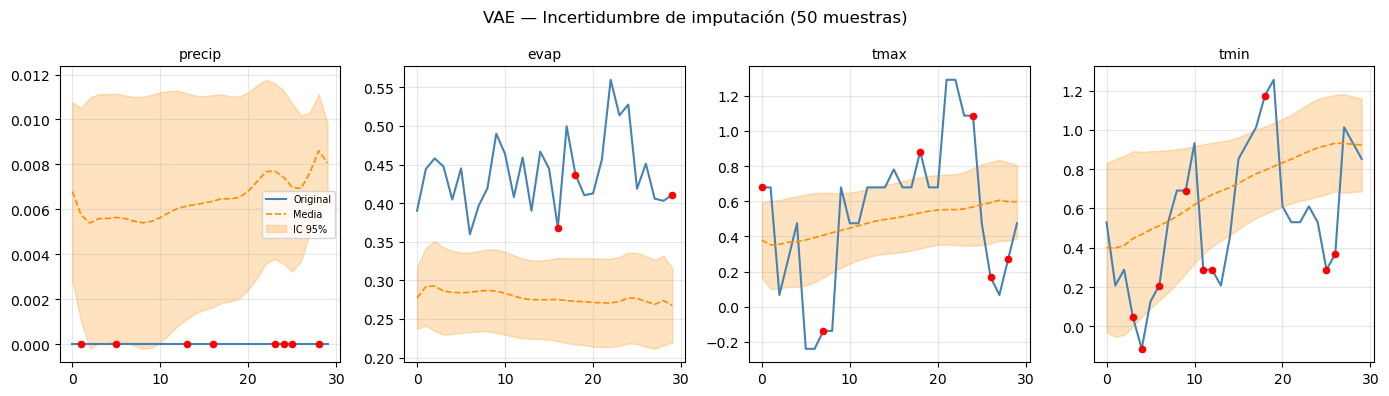

In [24]:
# ─── Imputación probabilística: múltiples muestras + intervalo de confianza ──
model.eval()
si = sidxs[0].item()
Xs_1 = Xs[[si]].to(DEVICE)
ev_1 = ev_m[[si]].to(DEVICE)

N_S = 50
samples = []
with torch.no_grad():
    for _ in range(N_S):
        recon, *_ = model(Xs_1 * ev_1)
        samples.append(recon.cpu()[0])   # (T, F)
samples = torch.stack(samples)           # (N_S, T, F)

mu_s  = samples.mean(0).numpy()
std_s = samples.std(0).numpy()

fig, axes = plt.subplots(1, N_FEAT, figsize=(14, 4))
fig.suptitle(f'VAE — Incertidumbre de imputación ({N_S} muestras)', fontsize=12)
for fi, (ax, var) in enumerate(zip(axes, VARIABLES)):
    orig = Xs[si, :, fi].numpy()
    gm   = gt_m[si, :, fi].bool().numpy()
    ax.plot(days, orig, 'steelblue', lw=1.5, label='Original', zorder=3)
    ax.plot(days, mu_s[:, fi], 'darkorange', lw=1.2, ls='--', label='Media', zorder=4)
    ax.fill_between(days,
                    mu_s[:, fi] - 1.96*std_s[:, fi],
                    mu_s[:, fi] + 1.96*std_s[:, fi],
                    alpha=0.25, color='darkorange', label='IC 95%')
    ax.scatter(days[gm], orig[gm], color='red', s=20, zorder=5)
    ax.set_title(var, fontsize=10)
    if fi == 0: ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "vae_incertidumbre.png", dpi=120, bbox_inches='tight')
plt.show()


## 9 — Guardado de métricas

In [25]:
rows = []
for var, m in vae_eval.items():
    r = dict(m); r['modelo'] = 'VAE'; rows.append(r)
df_vae = pd.DataFrame(rows)
df_vae.to_csv(REPORTS_DIR / "metrics_vae.csv", index=False)

print("Métricas VAE (MCAR 20%, espacio escalado):")
print(df_vae[["variable","n_mcar","rmse","mae","r2","nse"]].set_index("variable").round(4))
print(f"\nGuardado: {REPORTS_DIR / 'metrics_vae.csv'}")


Métricas VAE (MCAR 20%, espacio escalado):
          n_mcar    rmse     mae      r2     nse
variable                                        
precip    196368  0.0225  0.0085  0.0416  0.0416
evap      100832  0.0815  0.0638  0.3351  0.3351
tmax      195614  0.4455  0.3273  0.8042  0.8042
tmin      195037  0.3179  0.2388  0.9022  0.9022

Guardado: /home/sebastian/Documentos/Tec/Proyecto_Residencias/Residencias_Imputacion_Generativa_Hidrometeorologica-main/reports/modelos_generativos/metrics_vae.csv


## 10 — Análisis y conclusiones

### Ventajas del VAE frente al Autoencoder determinista
| Aspecto | Autoencoder | VAE |
|---------|-------------|-----|
| Salida | Determinista | Distribución — N muestras |
| Espacio latente | Sin regularización | Regularizado → N(0,I) |
| Incertidumbre | No | Sí — IC por simulación |
| Diversidad | Baja | Alta — muestras distintas |

### Validación de estructura temporal (KPSS y ACF/PACF)
El VAE muestrea múltiples imputaciones del espacio latente, lo que puede introducir variabilidad artificial. Se espera:
- `preserva_estacionariedad = True`: la media de las N muestras mantiene el régimen estacionario/no estacionario de la serie original.
- ACF/PACF similar entre original e imputado en lags bajos (1–7), donde la autocorrelación hidrometeorológica es más fuerte.

### Referencia de quality gates (modelos base)
| Variable | Mejor baseline NSE | VAE NSE | Δ NSE |
|----------|--------------------|---------|-------|
| precip   | XGBoost 0.1394     | 0.0416  | −0.098 |
| evap     | XGBoost 0.6891     | 0.3351  | −0.354 |
| tmax     | BiGRU   0.8518     | 0.8042  | −0.050 |
| tmin     | BiGRU   0.9389     | 0.9022  | −0.037 |

El VAE no supera a los modelos base en ninguna variable. Para **tmax** y **tmin** la brecha es pequeña (−0.050 y −0.037), lo que indica que el espacio latente regularizado captura adecuadamente la estructura de temperatura. Sin embargo, la caída es notable en **evap** (−0.354 puntos) y en **precip** (−0.098 puntos).

#### Por qué el VAE degrada evap respecto al baseline
El VAE optimiza la ELBO = Masked-MSE + β·KL. El término KL fuerza q(z|x) → N(0,I), lo que regulariza el espacio latente pero introduce un sesgo de sobre-suavizado en la reconstrucción. La evapotranspiración presenta variabilidad estacional de amplitud media-alta (rango normalizado ≈ 0.4–0.6): suficiente para que la regularización KL borre información de alta frecuencia que el Autoencoder determinista sí conserva. En contraste, temperatura (tmax/tmin) tiene autocorrelación muy alta (ρ₁ ≈ 0.65) y el VAE solo necesita capturar la tendencia suave, lo que el espacio latente regularizado hace bien. Para precipitación, el NSE bajo (0.042) refleja la distribución zero-inflated propia de la variable, no una limitación específica del VAE.

### Archivos generados
- `models/modelos_generativos/vae_best.pt`
- `reports/modelos_generativos/metrics_vae.csv`
- `reports/modelos_generativos/figuras/vae_*.png`

---